# Phase 2 - Step 6: Baseline Model

This notebook trains a baseline `LogisticRegression` model with stratified 80/20 train/test split, handles class imbalance, and evaluates standard classification metrics.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)

processed_dir = Path("data/processed")
df = pd.read_csv(processed_dir / "employee_attrition_processed.csv")

# Feature engineering
df['income_per_year_at_company'] = df['MonthlySalary'] * 12.0 / (df['YearsAtCompany'] + 1.0)
df['promotion_gap_ratio'] = (2026.0 - df['LastPromotionYear']) / (df['YearsAtCompany'] + 1.0)
df['overtime_ratio'] = df['OvertimeHoursPerMonth'] / 160.0
df['leave_utilization'] = df['LeavesTaken'] / 20.0
df['work_life_satisfaction'] = df['WorkLifeBalanceScore'] * df['CustomerSatisfaction']

target_col = 'AttritionRisk'
y = df[target_col].map({'Yes': 1, 'No': 0}).values
drop_cols = ['EmployeeID', 'Name', 'PhoneNumber', 'JoiningDate', 'LastLeaveDate', target_col, 'CountryCode']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()

# Stratified 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train size: {len(X_train)} (Positive: {sum(y_train)}), Test size: {len(X_test)} (Positive: {sum(y_test)})")

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
    ]
)

baseline_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

baseline_pipe.fit(X_train, y_train)
y_pred = baseline_pipe.predict(X_test)
y_proba = baseline_pipe.predict_proba(X_test)[:, 1]

prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("=== BASELINE LOGISTIC REGRESSION RESULTS ===")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['No (Active)', 'Yes (Attrition)']))


Train size: 400 (Positive: 44), Test size: 100 (Positive: 11)
=== BASELINE LOGISTIC REGRESSION RESULTS ===
Precision: 0.8000
Recall:    0.7273
F1-Score:  0.7619
ROC-AUC:   0.9837

Classification Report:
                  precision    recall  f1-score   support

    No (Active)       0.97      0.98      0.97        89
Yes (Attrition)       0.80      0.73      0.76        11

       accuracy                           0.95       100
      macro avg       0.88      0.85      0.87       100
   weighted avg       0.95      0.95      0.95       100



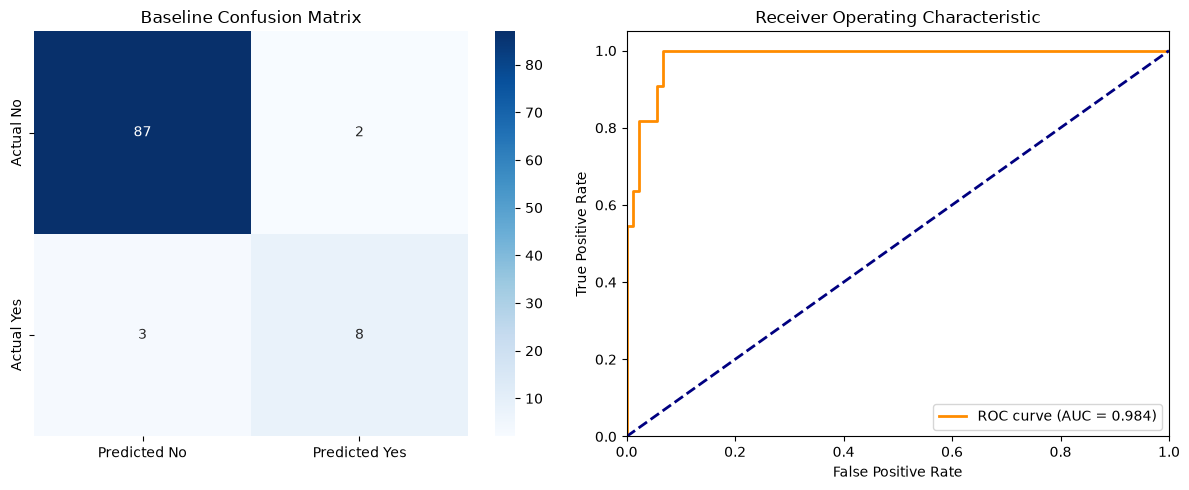


CRITICAL INSIGHT:
Accuracy alone is insufficient for attrition modeling because the dataset has ~89% negative class balance.
A trivial dummy model that predicts 'No' for every employee achieves 89% accuracy while having 0% Recall.
In HR risk mitigation, Recall and F1 are the primary metrics because failing to identify an at-risk employee has high retention cost.



In [2]:
# Visualizations: Confusion Matrix & ROC Curve
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
ax[0].set_title('Baseline Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.3f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('Receiver Operating Characteristic')
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print("""
CRITICAL INSIGHT:
Accuracy alone is insufficient for attrition modeling because the dataset has ~89% negative class balance.
A trivial dummy model that predicts 'No' for every employee achieves 89% accuracy while having 0% Recall.
In HR risk mitigation, Recall and F1 are the primary metrics because failing to identify an at-risk employee has high retention cost.
""")
